In [1]:
import pickle as pkl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

plt.style.use("seaborn-v0_8-colorblind")

matplotlib.rcParams.update({'font.size': 24})

In [2]:
def pareto_frontier(points, maximize=False):
    points = np.asarray(points)
    n_points, n_obj = points.shape

    if maximize:
        maximize = [False] * n_obj
    else:
        maximize = [True] * n_obj
        

    # Convert maximization to minimization
    cost = points.copy()
    for i, max_ in enumerate(maximize):
        if max_:
            cost[:, i] = -cost[:, i]

    is_pareto = np.ones(n_points, dtype=bool)

    for i in range(n_points):
        if is_pareto[i]:
            # A point is dominated if another point is no worse in all objectives
            # and strictly better in at least one
            dominated = np.all(cost <= cost[i], axis=1) & np.any(cost < cost[i], axis=1)
            is_pareto[dominated] = False

    return is_pareto

In [3]:
def results_to_df(results_list, dataset, sampling_method, rec_method):
    res = []
    for config in results_list:
        if "e" in config.keys():
            e = config["e"]
        else:
            e = np.inf
        b = config["b"]
        test_mae = config["test_mae"]
        res.append((dataset, rec_method, sampling_method, e, b, test_mae))
    
    return pd.DataFrame.from_records(res, columns=["dataset", "recsys", "method", "e", "b", "test_mae"])

def read_recsys_data(dataset, seeds=[0, 1, 2, 3, 4]):
    def results_to_df(results_list, dataset, sampling_method, rec_method):
        res = []
        for config in results_list:
            if "e" in config.keys():
                e = config["e"]
            else:
                e = np.inf
            b = config["b"]
            test_mae = config["test_mae"]
            res.append((dataset, rec_method, sampling_method, e, b, test_mae))
        return pd.DataFrame.from_records(res, columns=["dataset", "recsys", "method", "e", "b", "test_mae"])

    results_df = pd.DataFrame()
    for s in seeds:
        with open(dataset + "/MetaMF_s" + str(s) +".baseline", "rb") as f:
            meta_bsl = pkl.load(f)
            meta_bsl_df = results_to_df(meta_bsl, dataset, "baseline", "MetaMF")
        with open(dataset + "/NoMetaMF_s" + str(s) +".baseline", "rb") as f:
            nometa_bsl = pkl.load(f)
            nometa_bsl_df = results_to_df(nometa_bsl, dataset, "baseline", "NoMetaMF")
            
        with open(dataset + "/MetaMF_s" + str(s) +".random_dp", "rb") as f:
            meta_rand = pkl.load(f)
            meta_rand_df = results_to_df(meta_rand, dataset, "random_dp", "MetaMF")
        with open(dataset + "/NoMetaMF_s" + str(s) +".random_dp", "rb") as f:
            nometa_rand = pkl.load(f)
            nometa_rand_df = results_to_df(nometa_rand, dataset, "random_dp", "NoMetaMF")
            
        with open(dataset + "/MetaMF_s" + str(s) +".ister_dp", "rb") as f:
            meta_ister = pkl.load(f)
            meta_ister_df = results_to_df(meta_ister, dataset, "ister_dp", "MetaMF")
        with open(dataset + "/NoMetaMF_s" + str(s) +".ister_dp", "rb") as f:
            nometa_ister = pkl.load(f)
            nometa_ister_df = results_to_df(nometa_ister, dataset, "ister_dp", "NoMetaMF")
            
        results_per_seed_df = pd.concat([meta_bsl_df, nometa_bsl_df, meta_rand_df, nometa_rand_df, meta_ister_df, nometa_ister_df])
        results_df = pd.concat([results_df, results_per_seed_df])
    return results_df

def read_attacker_data(dataset):
    def results_to_df(results_list, dataset, sampling_method, bsl=False):
        res = []
        for config in results_list:
            b = config["b"]
            if (b == 1 or b == 0) and sampling_method != "baseline" and not bsl:
                continue

            if sampling_method.endswith("_dp"):
                e = config["e"]
            else:
                e = np.inf
            test_bacc = config["test_bacc"]
            e = config["e"]
            res.append((dataset, sampling_method, e, b, test_bacc))
        return pd.DataFrame.from_records(res, columns=["dataset", "sampling", "e", "b", "test_bacc"])
    
    PATH = dataset + "/"
    with open(PATH + "attacker.baseline", "rb") as f:
        baseline_results = pkl.load(f)
        baseline_results_df = results_to_df(baseline_results, dataset, "baseline")
    with open(PATH + "attacker.random_dp", "rb") as f:
        results = pkl.load(f)
        random_dp_df = results_to_df(results, dataset, "random_dp")
    with open(PATH + "attacker.ister_dp", "rb") as f:
        results = pkl.load(f)
        ister_dp_df = results_to_df(results, dataset, "ister_dp")
    results_df = pd.concat([baseline_results_df, random_dp_df, ister_dp_df]).reset_index(drop=True)
    
    return results_df

def add_baseline(results_df, method, e):
    bsl = results_df[(results_df["method"] == "baseline") & ((results_df["e"] == np.inf) | (results_df["e"] == e))]
    method = results_df[(results_df["method"] == method) & (results_df["e"] == e)]
    method = pd.concat([bsl, method]).sort_values(by=["e", "b"], ascending=False)
    return method

In [4]:
ml1m_recsys_results_df = read_recsys_data("ml1m", seeds=[0, 1, 2, 3, 4])
ml1m_recsys_results_df = ml1m_recsys_results_df.groupby(["recsys", "method", "e", "b"])["test_mae"].mean().reset_index()

ml1m_attacker_results_df = read_attacker_data("ml1m")

ml1m_df = ml1m_recsys_results_df.merge(ml1m_attacker_results_df, left_on=["method", "e", "b"], right_on=["sampling", "e", "b"])
ml1m_df.drop(columns=["sampling", "dataset"], inplace=True)

meta_bsl = ml1m_df[(ml1m_df["recsys"] == "MetaMF") & (ml1m_df["b"] == 1)]["test_mae"].values
meta_df = ml1m_df[(ml1m_df["recsys"] == "MetaMF")].copy()
meta_df["rel_mae"] = (ml1m_df[(ml1m_df["recsys"] == "MetaMF")]["test_mae"] - meta_bsl) / meta_bsl

nometa_bsl = ml1m_df[(ml1m_df["recsys"] == "NoMetaMF") & (ml1m_df["b"] == 1)]["test_mae"].values
nometa_df = ml1m_df[(ml1m_df["recsys"] == "NoMetaMF")].copy()
nometa_df["rel_mae"] = (ml1m_df[(ml1m_df["recsys"] == "NoMetaMF")]["test_mae"] - nometa_bsl) / nometa_bsl

meta_bsl = ml1m_df[(ml1m_df["recsys"] == "MetaMF") & (ml1m_df["b"] == 1)]["test_bacc"].values
meta_df["rel_bacc"] = (ml1m_df[(ml1m_df["recsys"] == "MetaMF")]["test_bacc"] - meta_bsl) / meta_bsl

nometa_bsl = ml1m_df[(ml1m_df["recsys"] == "NoMetaMF") & (ml1m_df["b"] == 1)]["test_bacc"].values
nometa_df["rel_bacc"] = (ml1m_df[(ml1m_df["recsys"] == "NoMetaMF")]["test_bacc"] - nometa_bsl) / nometa_bsl

ml1m_df = pd.concat([meta_df, nometa_df]).reindex()
ml1m_df.head()

,recsys,method,e,b,test_mae,test_bacc,rel_mae,rel_bacc
0,MetaMF,baseline,0.1,0.0,0.756765,0.717591,0.103715,-0.034063
2,MetaMF,baseline,1.0,0.0,0.721618,0.727114,0.052454,-0.021245
4,MetaMF,baseline,2.0,0.0,0.702737,0.738977,0.024917,-0.005276
6,MetaMF,baseline,3.0,0.0,0.698506,0.743791,0.018746,0.001204
8,MetaMF,baseline,inf,1.0,0.685652,0.742897,0.000000,0.000000


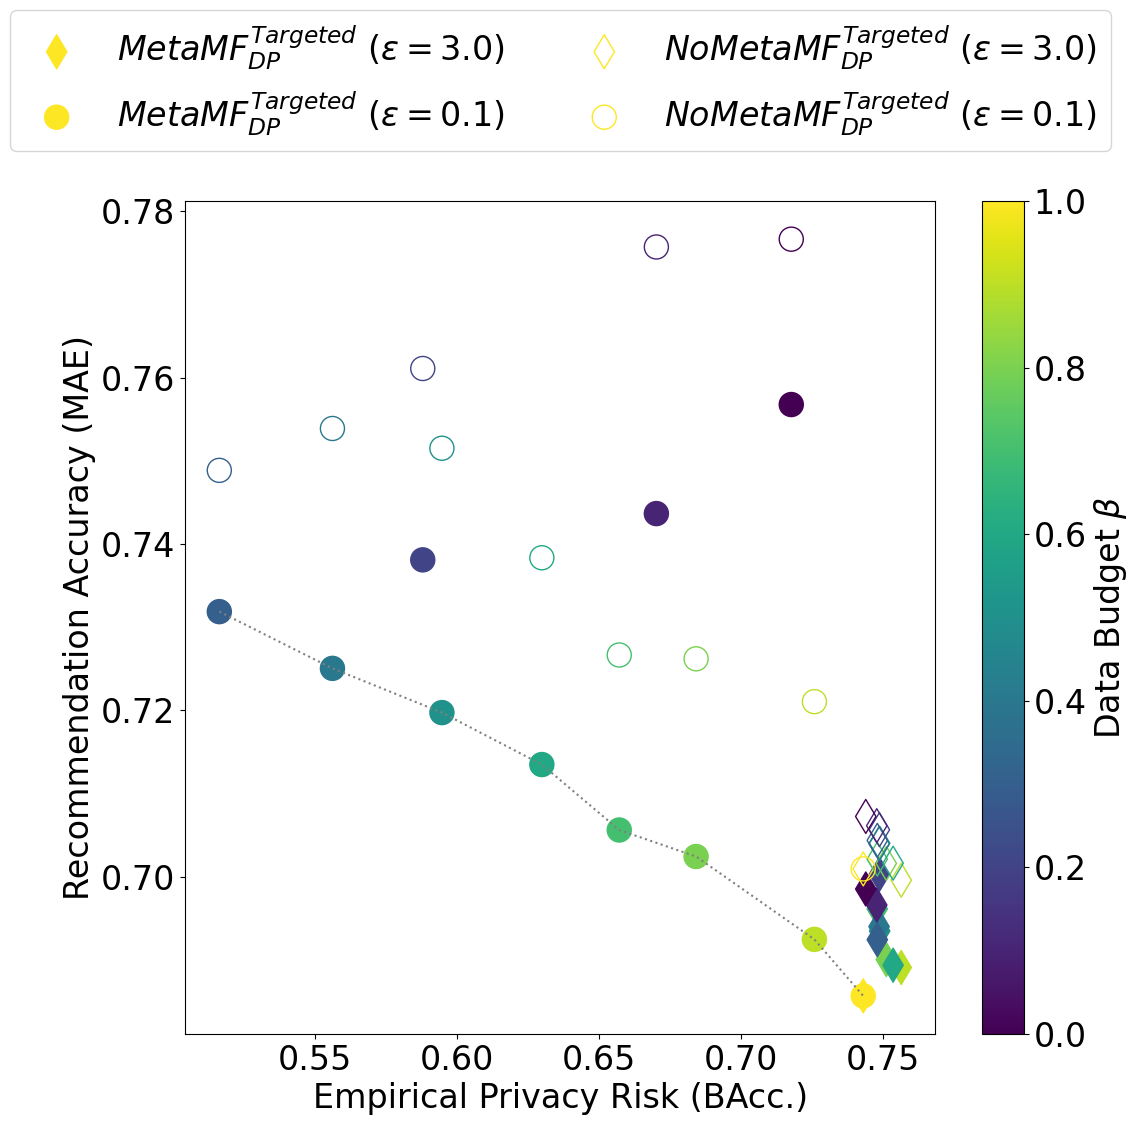

In [5]:
plt.figure(figsize=(12, 12))

meta_df = ml1m_df[ml1m_df["recsys"] == "MetaMF"]
nometa_df = ml1m_df[ml1m_df["recsys"] == "NoMetaMF"]

colors_b = ["C0", "C1", "C2", "C3", "C4", "C5"]
markers_e = ["d", "o", "v", "s"]
epsilons = [3, 0.1]
meta_all_points, nometa_all_points = [], []
# metamf
for e_idx, e in enumerate(epsilons):
    meta_e_df = add_baseline(meta_df, method="ister_dp", e=e)
    values = meta_e_df[["test_bacc", "test_mae"]].values
    #values = meta_e_df[["rel_bacc", "rel_mae"]].values
    betas = meta_e_df["b"].values
    label = r"$MetaMF^{Targeted}_{DP}\ (\epsilon=%.1f)$" % e
    sc = plt.scatter(values[:, 0], values[:, 1], c=betas, marker=markers_e[e_idx], cmap='viridis', label=label, s=300)
    meta_all_points.extend(values.tolist())

# nometamf
for e_idx, e in enumerate(epsilons):
    nometa_e_df = add_baseline(nometa_df, method="ister_dp", e=e)
    values = nometa_e_df[["test_bacc", "test_mae"]].values
    #values = nometa_e_df[["rel_bacc", "rel_mae"]].values
    betas = nometa_e_df["b"].values
    label = r"$NoMetaMF^{Targeted}_{DP}\ (\epsilon=%.1f)$" % e
    sc = plt.scatter(values[:, 0], values[:, 1], edgecolors=plt.cm.viridis(betas), marker=markers_e[e_idx], facecolors='none', label=label, s=300)
    nometa_all_points.extend(values.tolist())

plt.colorbar(sc, label=r'Data Budget $\beta$')
plt.xlabel("Empirical Privacy Risk (BAcc.)")
plt.ylabel("Recommendation Accuracy (MAE)")
plt.legend(ncol=2, loc='upper center', bbox_to_anchor=(0.5, 1.25))

all_points = np.array(meta_all_points + nometa_all_points)
mask = pareto_frontier(all_points, maximize=False)
frontier = np.array(sorted(all_points[mask], key=lambda t: t[0]))
plt.plot(frontier[:, 0], frontier[:, 1], c="gray", linestyle='dotted')

plt.tight_layout()
#plt.savefig("figures/ml1m_trade_off.png", dpi=300)

In [6]:
bx_recsys_results_df = read_recsys_data("bx", seeds=[0, 1, 2, 3, 4])
bx_recsys_results_df = bx_recsys_results_df.groupby(["recsys", "method", "e", "b"])["test_mae"].mean().reset_index()

bx_attacker_results_df = read_attacker_data("bx")

bx_df = bx_recsys_results_df.merge(bx_attacker_results_df, left_on=["method", "e", "b"], right_on=["sampling", "e", "b"])
bx_df.drop(columns=["sampling", "dataset"], inplace=True)

meta_bsl = bx_df[(bx_df["recsys"] == "MetaMF") & (bx_df["b"] == 1)]["test_mae"].values
meta_df = bx_df[(bx_df["recsys"] == "MetaMF")].copy()
meta_df["rel_mae"] = (bx_df[(bx_df["recsys"] == "MetaMF")]["test_mae"] - meta_bsl) / meta_bsl

nometa_bsl = bx_df[(bx_df["recsys"] == "NoMetaMF") & (bx_df["b"] == 1)]["test_mae"].values
nometa_df = bx_df[(bx_df["recsys"] == "NoMetaMF")].copy()
nometa_df["rel_mae"] = (bx_df[(bx_df["recsys"] == "NoMetaMF")]["test_mae"] - nometa_bsl) / nometa_bsl

meta_bsl = bx_df[(bx_df["recsys"] == "MetaMF") & (bx_df["b"] == 1)]["test_bacc"].values
meta_df["rel_bacc"] = (bx_df[(bx_df["recsys"] == "MetaMF")]["test_bacc"] - meta_bsl) / meta_bsl

nometa_bsl = bx_df[(bx_df["recsys"] == "NoMetaMF") & (bx_df["b"] == 1)]["test_bacc"].values
nometa_df["rel_bacc"] = (bx_df[(bx_df["recsys"] == "NoMetaMF")]["test_bacc"] - nometa_bsl) / nometa_bsl

bx_df = pd.concat([meta_df, nometa_df]).reindex()
bx_df.head()

,recsys,method,e,b,test_mae,test_bacc,rel_mae,rel_bacc
0,MetaMF,baseline,0.1,0.0,1.503924,0.641873,0.275729,-0.024767
2,MetaMF,baseline,1.0,0.0,0.904995,0.639665,-0.232322,-0.028121
4,MetaMF,baseline,2.0,0.0,0.738709,0.663039,-0.373378,0.007392
6,MetaMF,baseline,3.0,0.0,1.182116,0.649834,0.002750,-0.012670
8,MetaMF,baseline,inf,1.0,1.178874,0.658174,0.000000,0.000000


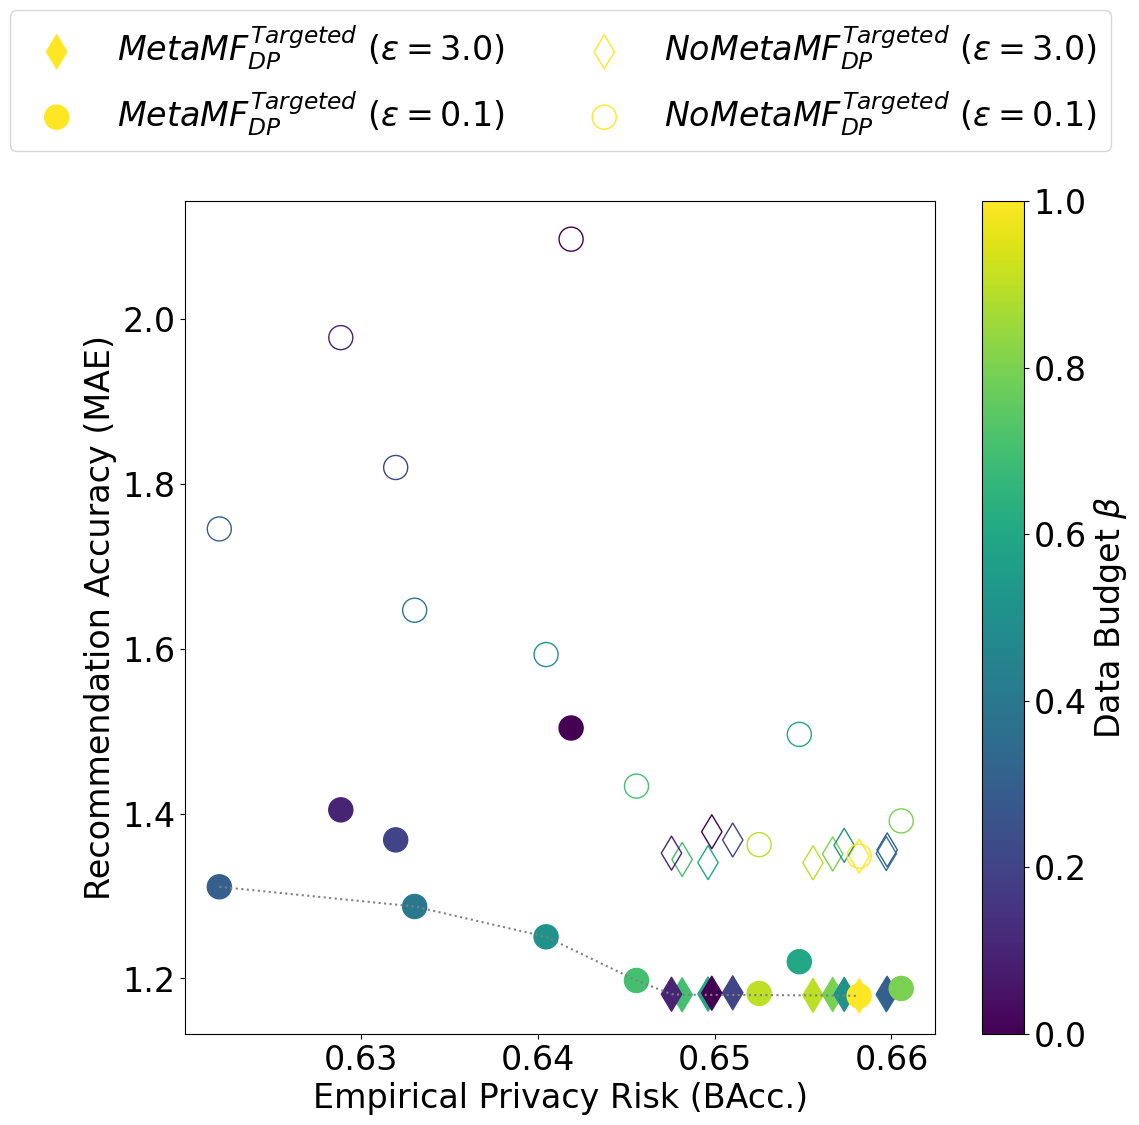

In [7]:
plt.figure(figsize=(12, 12))

meta_df = bx_df[bx_df["recsys"] == "MetaMF"]
nometa_df = bx_df[bx_df["recsys"] == "NoMetaMF"]

colors_b = ["C0", "C1", "C2", "C3", "C4", "C5"]
markers_e = ["d", "o", "v", "s"]
epsilons = [3, 0.1]
meta_all_points, nometa_all_points = [], []

# metamf
for e_idx, e in enumerate(epsilons):
    meta_e_df = add_baseline(meta_df, method="ister_dp", e=e)
    values = meta_e_df[["test_bacc", "test_mae"]].values
    betas = meta_e_df["b"].values
    label = r"$MetaMF^{Targeted}_{DP}\ (\epsilon=%.1f)$" % e
    sc = plt.scatter(values[:, 0], values[:, 1], c=betas, marker=markers_e[e_idx], cmap='viridis', label=label, s=300)
    meta_all_points.extend(values.tolist())

# nometamf
for e_idx, e in enumerate(epsilons):
    nometa_e_df = add_baseline(nometa_df, method="ister_dp", e=e)
    values = nometa_e_df[["test_bacc", "test_mae"]].values
    betas = nometa_e_df["b"].values
    label = r"$NoMetaMF^{Targeted}_{DP}\ (\epsilon=%.1f)$" % e
    sc = plt.scatter(values[:, 0], values[:, 1], edgecolors=plt.cm.viridis(betas), marker=markers_e[e_idx], facecolors='none', label=label, s=300)
    nometa_all_points.extend(values.tolist())

plt.colorbar(sc, label=r'Data Budget $\beta$')
plt.xlabel("Empirical Privacy Risk (BAcc.)")
plt.ylabel("Recommendation Accuracy (MAE)")
plt.legend(ncol=2, loc='upper center', bbox_to_anchor=(0.5, 1.25))

all_points = np.array(meta_all_points + nometa_all_points)
mask = pareto_frontier(all_points, maximize=False)
frontier = np.array(sorted(all_points[mask], key=lambda t: t[0]))
plt.plot(frontier[:, 0], frontier[:, 1], c="gray", linestyle='dotted')

plt.tight_layout()
#plt.savefig("figures/bx_trade_off.png", dpi=300)

C:\Users\pmuellner\AppData\Local\Temp\ipykernel_7076\4049671230.py:41: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(values[:, 0], values[:, 1],
C:\Users\pmuellner\AppData\Local\Temp\ipykernel_7076\4049671230.py:41: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(values[:, 0], values[:, 1],
C:\Users\pmuellner\AppData\Local\Temp\ipykernel_7076\4049671230.py:90: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(values[:, 0], values[:, 1],
C:\Users\pmuellner\AppData\Local\Temp\ipykernel_7076\4049671230.py:90: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(values[:, 0], values[:, 1],
C:\Users\pmuellner\AppData\Local\Temp\ipykernel_7076\4049671230.py:141: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.t

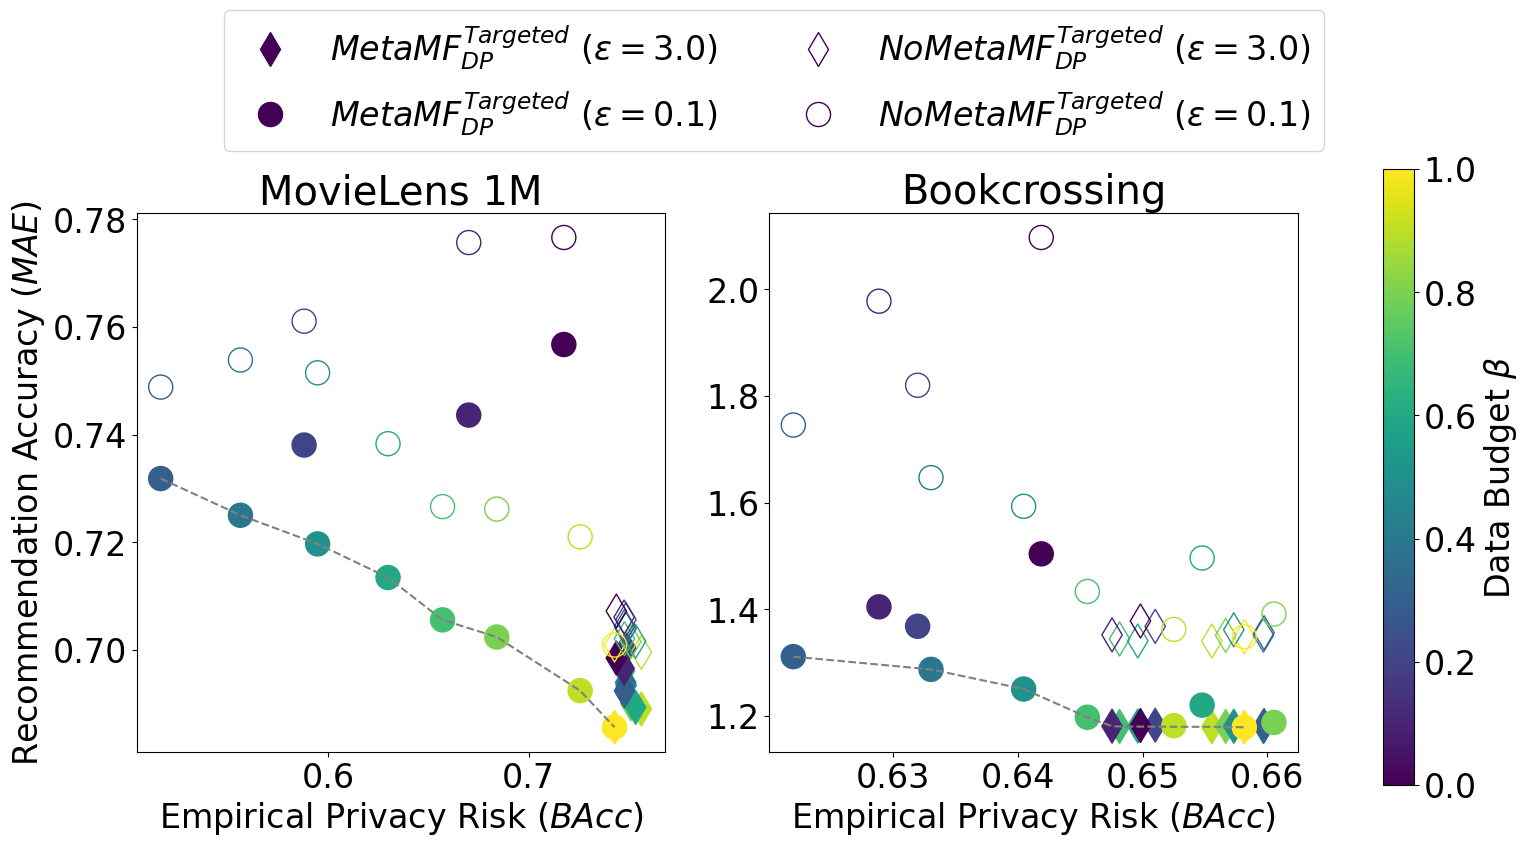

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

epsilons = [3, 0.1]
markers_e = ["d", "o", "v", "s"]

# We'll store last scatter for colorbar
last_scatter = None


# ===================== LEFT: ML1M =====================
ax = axes[0]

meta_df = ml1m_df[ml1m_df["recsys"] == "MetaMF"]
nometa_df = ml1m_df[ml1m_df["recsys"] == "NoMetaMF"]

meta_all_points, nometa_all_points = [], []

# meta
for e_idx, e in enumerate(epsilons):
    meta_e_df = add_baseline(meta_df, method="ister_dp", e=e)
    values = meta_e_df[["test_bacc", "test_mae"]].values
    betas = meta_e_df["b"].values

    label = r"$MetaMF^{Targeted}_{DP}\ (\epsilon=%.1f)$" % e
    sc = ax.scatter(values[:, 0], values[:, 1],
                    c=betas, cmap="viridis",
                    marker=markers_e[e_idx],
                    label=label, s=300)
    last_scatter = sc
    meta_all_points.extend(values.tolist())

# nometa
for e_idx, e in enumerate(epsilons):
    nometa_e_df = add_baseline(nometa_df, method="ister_dp", e=e)
    values = nometa_e_df[["test_bacc", "test_mae"]].values
    betas = nometa_e_df["b"].values

    label = r"$NoMetaMF^{Targeted}_{DP}\ (\epsilon=%.1f)$" % e
    ax.scatter(values[:, 0], values[:, 1],
               cmap="viridis",
               edgecolors=plt.cm.viridis(betas),
               facecolors="none",
               marker=markers_e[e_idx],
               label=label, s=300)

    nometa_all_points.extend(values.tolist())

# Pareto
all_points = np.array(meta_all_points + nometa_all_points)
mask = pareto_frontier(all_points, maximize=False)
frontier = np.array(sorted(all_points[mask], key=lambda t: t[0]))
ax.plot(frontier[:, 0], frontier[:, 1], c="gray", linestyle="dashed")

ax.set_title("MovieLens 1M")
ax.set_xlabel(r"Empirical Privacy Risk ($BAcc$)")
ax.set_ylabel(r"Recommendation Accuracy ($MAE$)")


# ===================== RIGHT: BX =====================
ax = axes[1]

meta_df = bx_df[bx_df["recsys"] == "MetaMF"]
nometa_df = bx_df[bx_df["recsys"] == "NoMetaMF"]

meta_all_points, nometa_all_points = [], []

# meta
for e_idx, e in enumerate(epsilons):
    meta_e_df = add_baseline(meta_df, method="ister_dp", e=e)
    values = meta_e_df[["test_bacc", "test_mae"]].values
    betas = meta_e_df["b"].values

    label = r"$MetaMF^{Targeted}_{DP}\ (\epsilon=%.1f)$" % e
    sc = ax.scatter(values[:, 0], values[:, 1],
                    c=betas, cmap="viridis",
                    marker=markers_e[e_idx],
                    label=label, s=300)
    last_scatter = sc
    meta_all_points.extend(values.tolist())

# nometa
for e_idx, e in enumerate(epsilons):
    nometa_e_df = add_baseline(nometa_df, method="ister_dp", e=e)
    values = nometa_e_df[["test_bacc", "test_mae"]].values
    betas = nometa_e_df["b"].values

    label = r"$NoMetaMF^{Targeted}_{DP}\ (\epsilon=%.1f)$" % e
    ax.scatter(values[:, 0], values[:, 1],
               cmap="viridis",
               edgecolors=plt.cm.viridis(betas),
               facecolors="none",
               marker=markers_e[e_idx],
               label=label, s=300)

    nometa_all_points.extend(values.tolist())

# Pareto
all_points = np.array(meta_all_points + nometa_all_points)
mask = pareto_frontier(all_points, maximize=False)
frontier = np.array(sorted(all_points[mask], key=lambda t: t[0]))
ax.plot(frontier[:, 0], frontier[:, 1], c="gray", linestyle="dashed")

ax.set_title("Bookcrossing")
ax.set_xlabel(r"Empirical Privacy Risk ($BAcc$)")


# ===================== SHARED COLORBAR =====================
cbar = fig.colorbar(last_scatter, ax=axes, fraction=0.025, pad=0.02)
cbar.set_label(r"Data Budget $\beta$")


# ===================== SHARED LEGEND =====================
from matplotlib.lines import Line2D
cmap = plt.cm.viridis
max_color = cmap(0)
# get labels only
_, labels = axes[0].get_legend_handles_labels()
legend_handles = [
    Line2D([0], [0], marker='d', linestyle='None',
           markerfacecolor=max_color, markeredgecolor=max_color,
           markersize=np.sqrt(300)),
    Line2D([0], [0], marker='o', linestyle='None',
           markerfacecolor=max_color, markeredgecolor=max_color,
           markersize=np.sqrt(300)),
    Line2D([0], [0], marker='d', linestyle='None',
           markerfacecolor='none', markeredgecolor=max_color,
           markersize=np.sqrt(300)),
    Line2D([0], [0], marker='o', linestyle='None',
           markerfacecolor='none', markeredgecolor=max_color,
           markersize=np.sqrt(300)),
]

fig.legend(legend_handles, labels,
           loc="upper center",
           ncol=2,
           bbox_to_anchor=(0.5, 1.1))


plt.tight_layout(rect=[0, 0, 0.85, 0.92])
#plt.savefig("figures/combined_trade_off.png", dpi=300, bbox_inches="tight")
plt.show()